In [13]:
import xarray as xr 
import matplotlib.pyplot as plt 
import os
from project.data_handling import * 
from shop.plotting.plotting_fxns import *

rgi_map = {}
for glacier in translate_rgi:
    six = translate_rgi[glacier]['6']
    rgi_map[six] = glacier
    rgi_map[glacier] = translate_rgi[glacier]

site_dict = {
    'wolverine':['N','B','EC'],
    'kahiltna':['K53','K17b'], 
    'kennicott':['GTL','GTH'], # ,'KC31'],
    'lemon_creek':['B','C','D'],
    'taku':['NWB1','TKG3'],
    'gulkana':['AU','B','D']
}

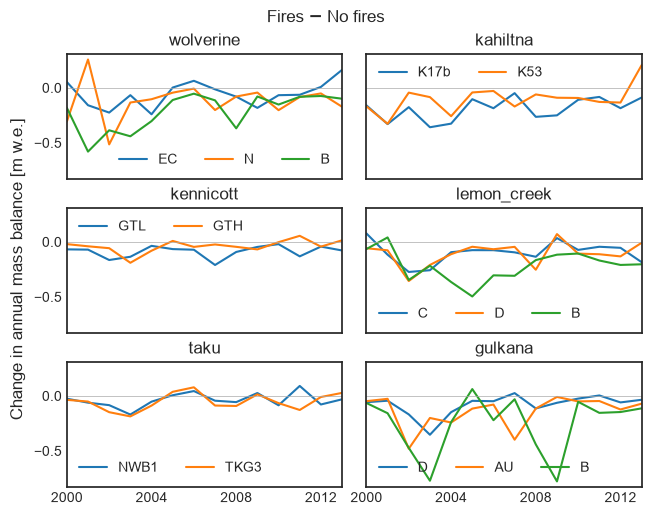

In [40]:
base_fp = '../Output/ukesm_base_0/'
nofire_fp = '../Output/ukesm_nofires_0/'

fig, axes = plt.subplots(3, 2, layout='constrained', sharey=True, sharex=True)
map_ax = {}
for glacier, ax in zip(site_dict, axes.flatten()):
    map_ax[glacier] = ax
                       
for fn in os.listdir(base_fp):
    if 'zarr' not in fn:
        continue

    ds_base = xr.open_dataset(base_fp + fn)
    ds_nofire = xr.open_dataset(nofire_fp + fn)

    site = ds_base.attrs['sites']
    glacier = rgi_map[ds_base.attrs['id']]
    
    mb_base = ((ds_base.accumulation - ds_base.melt + ds_base.refreeze)
               .resample(time='YS-OCT').sum())
    mb_nofire = ((ds_nofire.accumulation - ds_nofire.melt + ds_nofire.refreeze)
               .resample(time='YS-OCT').sum())
    
    difference = mb_base - mb_nofire
    years = mb_base.time.dt.year

    map_ax[glacier].plot(years, difference, label=site)

for glacier in map_ax:
    map_ax[glacier].set_title(glacier)
    n_sites = len(site_dict[glacier])
    map_ax[glacier].legend(ncols=n_sites)
    map_ax[glacier].set_xlim(2000, 2013)
    map_ax[glacier].axhline(0, linewidth=0.5, color='darkgray')
    map_ax[glacier].set_xticks([2000, 2004, 2008, 2012])

fig.supylabel('Change in annual mass balance [m w.e.]')
fig.suptitle('Fires $-$ No fires', y=1.04)
# plt.show()
plt.savefig('../figs/fires_vs_not.png', dpi=300, bbox_inches='tight')

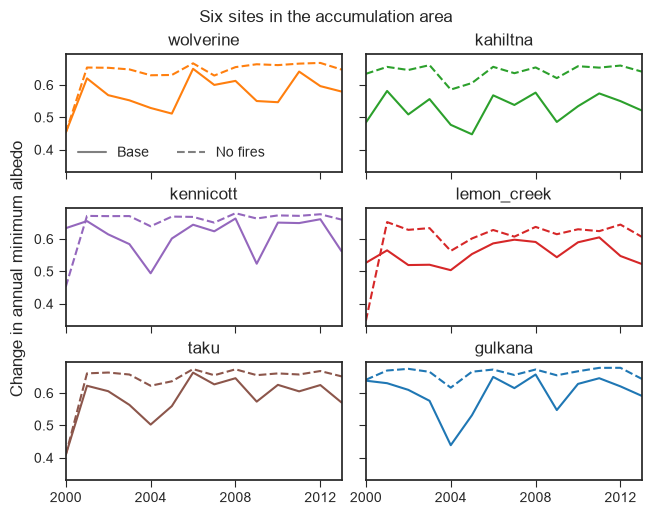

In [39]:
base_fp = '../Output/ukesm_base_0/'
nofire_fp = '../Output/ukesm_nofires_0/'

fig, axes = plt.subplots(3, 2, layout='constrained', sharey=True, sharex=True)
map_ax = {}
for glacier, ax in zip(site_dict, axes.flatten()):
    map_ax[glacier] = ax
                       
i = 0
for fn in os.listdir(base_fp):
    if 'zarr' not in fn:
        continue

    ds_base = xr.open_dataset(base_fp + fn)
    ds_nofire = xr.open_dataset(nofire_fp + fn)

    site = ds_base.attrs['sites']
    glacier = rgi_map[ds_base.attrs['id']]

    min_albedo_base = ds_base.albedo.resample(time='YS-APR').min()
    min_albedo_nofire = ds_nofire.albedo.resample(time='YS-APR').min()
    difference = min_albedo_base - min_albedo_nofire
    years = difference.time.dt.year

    if site not in ['GTH','K17b','D','EC','NWB1']:
        continue 

    if i > len(colors):
        i = i - len(colors)
    map_ax[glacier].plot(years, min_albedo_base, c=colors[i])
    map_ax[glacier].plot(years, min_albedo_nofire, c=colors[i], linestyle='--')
    i += 1 

for glacier, ax in map_ax.items():
    ax.set_title(glacier)
    ax.set_xlim(2000, 2013)
    ax.set_xticks([2000, 2004, 2008, 2012])
    ax.tick_params(length=5)

map_ax['wolverine'].plot(np.nan, np.nan, c='gray', label='Base')
map_ax['wolverine'].plot(np.nan, np.nan, c='gray', linestyle='--', label='No fires')
map_ax['wolverine'].legend(ncols=2)

fig.supylabel('Change in annual minimum albedo')
fig.suptitle('Six sites in the accumulation area', y=1.04)
plt.savefig('../figs/fires_vs_not_min_albedo.png', dpi=300, bbox_inches='tight')
# plt.show()

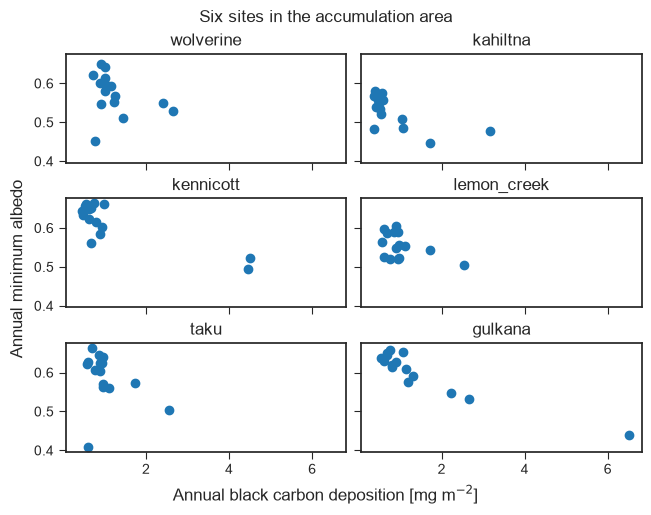

In [43]:
base_fp = '../Output/ukesm_base_0/'
nofire_fp = '../Output/ukesm_nofires_0/'

ds_dep = xr.open_zarr('../climate_data/MERRA2/reg01/BCDP002_reg01.zarr')

fig, axes = plt.subplots(3, 2, layout='constrained', sharey=True, sharex=True)
map_ax = {}
for glacier, ax in zip(site_dict, axes.flatten()):
    map_ax[glacier] = ax
                       
i = 0
for fn in os.listdir(base_fp):
    if 'zarr' not in fn:
        continue

    ds_base = xr.open_dataset(base_fp + fn)

    site = ds_base.attrs['sites']
    glacier = rgi_map[ds_base.attrs['id']]
    lat = float(ds_base.attrs['lat'])
    lon = float(ds_base.attrs['lon'])

    min_albedo_base = ds_base.albedo.resample(time='YS-APR').min()
    annual_dep = (ds_dep['BCDP002']
                  .sel(lat=lat, lon=lon, method='nearest')
                  .sortby('time').drop_duplicates('time')
                  .resample(time='YS-APR').sum()) * 3600 * 1e6
    annual_dep = annual_dep.sel(time=min_albedo_base.time)

    if site not in ['GTH','K17b','D','EC','NWB1']:
        continue 

    map_ax[glacier].scatter(annual_dep, min_albedo_base)
    map_ax[glacier].tick_params(length=5)
    map_ax[glacier].set_title(glacier)

fig.supylabel('Annual minimum albedo')
fig.supxlabel('Annual black carbon deposition [mg m$^{-2}$]')

fig.suptitle('Six sites in the accumulation area', y=1.04)
plt.savefig('../figs/bc_min_albedo_correlation.png', dpi=300, bbox_inches='tight')

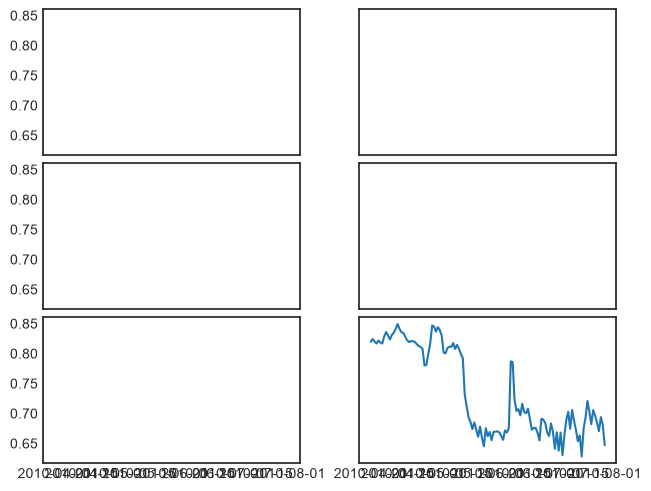

AssertionError: 

In [58]:
base_fp = '../Output/ukesm_base_0/'
nofire_fp = '../Output/ukesm_nofires_0/'

fig, axes = plt.subplots(3, 2, layout='constrained', sharey=True, sharex=True)
map_ax = {}
for glacier, ax in zip(site_dict, axes.flatten()):
    map_ax[glacier] = ax
                       
i = 0
for fn in os.listdir(base_fp):
    if 'zarr' not in fn:
        continue

    ds_base = xr.open_dataset(base_fp + fn)

    site = ds_base.attrs['sites']
    glacier = rgi_map[ds_base.attrs['id']]
    lat = float(ds_base.attrs['lat'])
    lon = float(ds_base.attrs['lon'])
    a_ice = float(ds_base.attrs['albedo_ice'])

    daily_albedo = ds_base.albedo.sel(
        time=pd.date_range(ds_base.time.values[0], ds_base.time.values[-1])
    )
    f = daily_albedo.sel(time=slice('2010-04-01','2010-08-01'))
    map_ax[glacier].plot(f.time, f.values)
    plt.show()
    assert 1==0
    annual_days = daily_albedo.groupby('time.year').map(lambda x: (x == a_ice).sum('time'))

    annual_dep = (ds_dep['BCDP002']
                  .sel(lat=lat, lon=lon, method='nearest')
                  .sortby('time').drop_duplicates('time')
                  .resample(time='YS-APR').sum()) * 3600 * 1e6
    annual_dep = annual_dep.sel(time=pd.to_datetime(
        [f'{year}-04-01' for year in annual_days.year.values]))  

    map_ax[glacier].scatter(annual_dep, annual_days)
    map_ax[glacier].tick_params(length=5)
    map_ax[glacier].set_title(glacier)
    map_ax[glacier].set_ylim(10, 150)

fig.supylabel('Days of ice exposure')
fig.suptitle('Six sites in the accumulation area', y=1.04)
plt.savefig('../figs/ice_exposure_days.png', dpi=300, bbox_inches='tight')